     country food_category  consumption  co2_emmission
0  Argentina          Pork        10.51          37.20
1  Argentina       Poultry        38.66          41.53
2  Argentina          Beef        55.48        1712.00
3  Argentina   Lamb & Goat         1.56          54.63
4  Argentina          Fish         4.36           6.96

Cluster results:
         country  Cluster
0      Argentina        0
1      Argentina        0
2      Argentina        0
3      Argentina        0
4      Argentina        0
...          ...      ...
1425  Bangladesh        0
1426  Bangladesh        0
1427  Bangladesh        0
1428  Bangladesh        0
1429  Bangladesh        0

[1430 rows x 2 columns]


/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_18592/996085302.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_col = df.select_dtypes(include="object").columns[0]


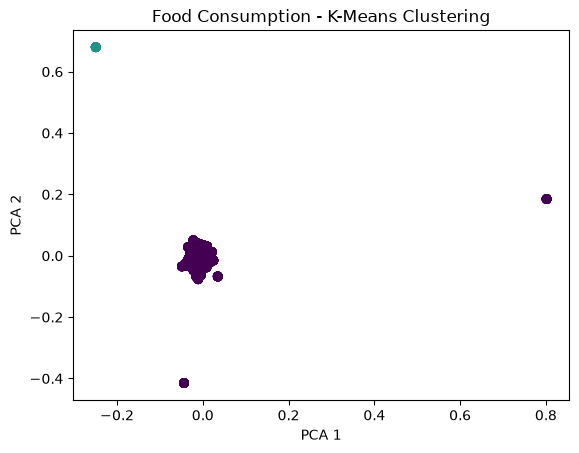

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv("food_consumption.csv")
print(df.head())

# Select text column
text_col = df.select_dtypes(include="object").columns[0]
df[text_col] = df[text_col].fillna("")

# NLP: TF-IDF
tfidf = TfidfVectorizer(stop_words="english")
X = tfidf.fit_transform(df[text_col])

# K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X)

print("\nCluster results:")
print(df[[text_col, "Cluster"]])

# PCA visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["Cluster"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Food Consumption - K-Means Clustering")
plt.show()

# Save result
df.to_csv("food_consumption_clustered.csv", index=False)